In [4]:

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from rapidfuzz import fuzz
import matplotlib.pyplot as plt

nltk.download('punkt')        
nltk.download('punkt_tab')    
nltk.download('stopwords')    
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print("Setup done!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Setup done!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:

corpus = [
    "Machine learning is a subset of artificial intelligence. It focuses on building systems that learn from data.",
    "Python is a popular programming language for data science and web development. It has simple syntax.",
    "Climate change refers to long-term shifts in temperatures and weather patterns. Human activities are the main driver.",
    "The stock market is where investors buy and sell shares of publicly traded companies."
]

query_doc = "Machine learning is part of artificial intelligence. It helps build systems that learn from data."

print("Query Doc:", query_doc)

Query Doc: Machine learning is part of artificial intelligence. It helps build systems that learn from data.


In [5]:
def clean_text(text):
    
    text = text.lower()
    words = word_tokenize(text)
    words = [word for word in words if word.isalpha() and word not in stop_words]
    return " ".join(words)

corpus_clean = [clean_text(doc) for doc in corpus]
query_clean = clean_text(query_doc)

print("Cleaned Query:", query_clean)

Cleaned Query: machine learning part artificial intelligence helps build systems learn data


In [6]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))

corpus_vectors = vectorizer.fit_transform(corpus_clean)
query_vector = vectorizer.transform([query_clean])


similarity_scores = cosine_similarity(query_vector, corpus_vectors)[0]


for i, score in enumerate(similarity_scores):
    print(f"Similarity with Doc {i+1}: {score*100:.1f}%")

Similarity with Doc 1: 75.5%
Similarity with Doc 2: 4.4%
Similarity with Doc 3: 0.0%
Similarity with Doc 4: 0.0%


In [7]:
THRESHOLD = 0.3

print(f"\n--- Results with {THRESHOLD*100}% threshold ---")
flagged = False
for i, score in enumerate(similarity_scores):
    if score > THRESHOLD:
        flagged = True
        print(f"PLAGIARISM ALERT: {score*100:.1f}% match with Doc {i+1}")
        print(f"Source text: {corpus[i]}\n")

if not flagged:
    print("No plagiarism detected above threshold.")


--- Results with 30.0% threshold ---
PLAGIARISM ALERT: 75.5% match with Doc 1
Source text: Machine learning is a subset of artificial intelligence. It focuses on building systems that learn from data.



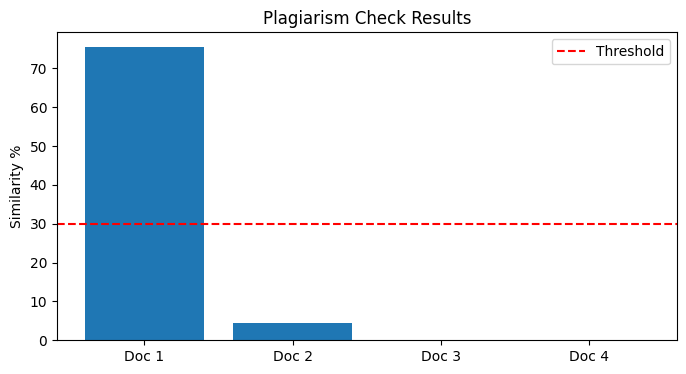

--- PLAGIARISM REPORT ---
Document Checked: Machine learning is part of artificial intelligence. It helps build systems that learn from data.
Highest Similarity Found: 75.5%
Status: Potential Plagiarism


In [8]:
plt.figure(figsize=(8,4))
plt.bar([f'Doc {i+1}' for i in range(len(corpus))], similarity_scores*100)
plt.axhline(y=THRESHOLD*100, color='r', linestyle='--', label='Threshold')
plt.ylabel('Similarity %')
plt.title('Plagiarism Check Results')
plt.legend()
plt.show()

total_plagiarism = max(similarity_scores) * 100
print("--- PLAGIARISM REPORT ---")
print(f"Document Checked: {query_doc}")
print(f"Highest Similarity Found: {total_plagiarism:.1f}%")
print(f"Status: {'Potential Plagiarism' if total_plagiarism > THRESHOLD*100 else 'Original Content'}")

In [9]:
print("\n--- Sentence Level Check ---")
query_sentences = sent_tokenize(query_doc)

for doc_idx, source_doc in enumerate(corpus):
    if similarity_scores[doc_idx] > 0.1: # Only check docs that are somewhat similar
        source_sentences = sent_tokenize(source_doc)
        for q_sent in query_sentences:
            for s_sent in source_sentences:
                score = fuzz.ratio(q_sent, s_sent)
                if score > 70: # 70% similar sentences
                    print(f"Match: '{q_sent}' ≈ '{s_sent}' | {score}% | From Doc {doc_idx+1}")


--- Sentence Level Check ---
Match: 'Machine learning is part of artificial intelligence.' ≈ 'Machine learning is a subset of artificial intelligence.' | 92.5925925925926% | From Doc 1
Match: 'It helps build systems that learn from data.' ≈ 'It focuses on building systems that learn from data.' | 85.41666666666666% | From Doc 1
